# Air Quality and Respiratory Health Prediction  
## Class 3: Modeling and Evaluation

### Objective
Develop, validate, and compare machine learning models to predict **`hospital_admissions`**.

### Target Variable
The target variable is **`hospital_admissions`**, which represents respiratory-related hospital admissions.

### ML Task
This is a **regression problem** because the target variable is numerical.

### Modeling Strategy
To avoid running too many models, only three models are used:

1. **Linear Regression**: baseline model  
2. **Ridge Regression**: regularized linear model  
3. **Random Forest Regressor**: nonlinear model  

### Validation Strategy
This notebook uses a proper three-way data split:

- **Training set**: used to train the models  
- **Validation set**: used to compare models and tune hyperparameters  
- **Test set**: used only once at the end for final model evaluation  

This prevents the test set from influencing model selection.

In [19]:
# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from itertools import product
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

In [20]:
# 2. Load ML-ready dataset from Class 1/2
possible_files = [
    "../data/air_quality_health_ml_ready.csv",
    "data/air_quality_health_ml_ready.csv",
    "air_quality_health_ml_ready.csv",
    "/mnt/data/air_quality_health_ml_ready.csv",
    "../data/air_quality_health_dataset.csv",
    "data/air_quality_health_dataset.csv",
    "air_quality_health_dataset.csv",
    "/mnt/data/air_quality_health_dataset.csv"
]

for file in possible_files:
    try:
        df = pd.read_csv(file)
        print(f"Loaded file: {file}")
        break
    except FileNotFoundError:
        continue
else:
    raise FileNotFoundError("No dataset found. Please run Class 1/2 first or check the data/ folder.")

# Fallback: if the raw dataset is loaded, create the engineered features used in Class 1/2.
if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    df["day"] = df["date"].dt.day
    df["dayofweek"] = df["date"].dt.dayofweek
    df["quarter"] = df["date"].dt.quarter
    df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)

pollution_cols = [col for col in ["aqi", "pm2_5", "pm10", "no2", "o3"] if col in df.columns]
if pollution_cols:
    if "pollution_mean" not in df.columns:
        df["pollution_mean"] = df[pollution_cols].mean(axis=1)
    if "pollution_max" not in df.columns:
        df["pollution_max"] = df[pollution_cols].max(axis=1)

if "pm_ratio" not in df.columns and {"pm2_5", "pm10"}.issubset(df.columns):
    pm_ratio = df["pm2_5"] / df["pm10"].replace(0, np.nan)
    pm_ratio = pm_ratio.clip(upper=10)
    df["pm_ratio"] = pm_ratio.fillna(pm_ratio.median())

print("Dataset shape:", df.shape)
df.head()


Loaded file: ../data/air_quality_health_ml_ready.csv
Dataset shape: (88489, 21)


,city,population_density,date,year,month,day,dayofweek,quarter,is_weekend,aqi,pm2_5,pm10,no2,o3,temperature,humidity,hospital_capacity,pollution_mean,pollution_max,pm_ratio,hospital_admissions
0,Los Angeles,Rural,2020-01-01,2020,1,1,2,1,0,65,34.0,52.7,2.2,38.5,33.5,33,1337,38.48,65.0,0.645161,5
1,Beijing,Urban,2020-01-02,2020,1,2,3,1,0,137,33.7,31.5,36.7,27.5,-1.6,32,1545,53.28,137.0,1.069841,4
2,London,Suburban,2020-01-03,2020,1,3,4,1,0,266,43.0,59.6,30.4,57.3,36.4,25,1539,91.26,266.0,0.721477,10
3,Mexico City,Urban,2020-01-04,2020,1,4,5,1,1,293,33.7,37.9,12.3,42.7,-1.0,67,552,83.92,293.0,0.889182,10
4,Delhi,Suburban,2020-01-05,2020,1,5,6,1,1,493,50.3,34.8,31.2,35.6,33.5,72,1631,128.98,493.0,1.445402,9


## 3. Define Features and Target

The target variable is **`hospital_admissions`**.  
The raw `date` column is removed from model features because structured time variables such as year, month, day of week, quarter, and weekend indicator are already available.

In [21]:
# 3. Define X and y
target = "hospital_admissions"

if target not in df.columns:
    raise ValueError(f"Target column '{target}' not found in dataset.")

X = df.drop(columns=[target])
y = df[target]

# Remove raw date column from model features
if "date" in X.columns:
    X = X.drop(columns=["date"])

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Features used:")
print(X.columns.tolist())

Feature matrix shape: (88489, 19)
Target shape: (88489,)
Features used:
['city', 'population_density', 'year', 'month', 'day', 'dayofweek', 'quarter', 'is_weekend', 'aqi', 'pm2_5', 'pm10', 'no2', 'o3', 'temperature', 'humidity', 'hospital_capacity', 'pollution_mean', 'pollution_max', 'pm_ratio']


## 4. Train / Validation / Test Split

The dataset is split into:

- **60% training set**: model fitting  
- **20% validation set**: model comparison and hyperparameter tuning  
- **20% test set**: final evaluation only after model selection  

The test set is not used during model training, tuning, or selection.

In [22]:
# 4. Train / validation / test split
# First, hold out 20% as the final test set.
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

# Then split the remaining 80% into 60% training and 20% validation.
# validation_size = 0.25 of train_val because 0.25 * 0.80 = 0.20 of the full dataset.
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.25,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

X_train: (53093, 19)
X_val: (17698, 19)
X_test: (17698, 19)
y_train: (53093,)
y_val: (17698,)
y_test: (17698,)


In [23]:
# 5. Preprocessing pipeline
numeric_features = X.select_dtypes(include=["int64", "float64", "int32", "float32", "bool"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", onehot)
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['year', 'month', 'day', 'dayofweek', 'quarter', 'is_weekend', 'aqi', 'pm2_5', 'pm10', 'no2', 'o3', 'temperature', 'humidity', 'hospital_capacity', 'pollution_mean', 'pollution_max', 'pm_ratio']
Categorical features: ['city', 'population_density']


## 6. Selected Models

Only three models are used to keep the modeling workflow focused:

1. **Linear Regression**: baseline model  
2. **Ridge Regression**: regularized linear model  
3. **Random Forest Regressor**: nonlinear model  

Model comparison and tuning are based on the **validation set**, not the test set.

In [24]:
# 6. Helper functions

def evaluate_predictions(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }


def fit_status_from_train_val(train_r2, val_r2):
    gap = train_r2 - val_r2
    if train_r2 < 0.50 and val_r2 < 0.50:
        return "Possible underfitting"
    elif gap > 0.15:
        return "Possible overfitting"
    else:
        return "Good fit"


def evaluate_train_validation(model_name, model, X_train, X_val, y_train, y_val):
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)

    train_metrics = evaluate_predictions(y_train, train_pred)
    val_metrics = evaluate_predictions(y_val, val_pred)

    train_r2 = train_metrics["R2"]
    val_r2 = val_metrics["R2"]
    r2_gap = train_r2 - val_r2

    return {
        "Model": model_name,
        "Train R2": train_r2,
        "Validation R2": val_r2,
        "R2 Gap": r2_gap,
        "Validation MAE": val_metrics["MAE"],
        "Validation RMSE": val_metrics["RMSE"],
        "Fit Status": fit_status_from_train_val(train_r2, val_r2)
    }

In [25]:
# 7. Model 1: Linear Regression baseline
linear_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_results = evaluate_train_validation(
    "Linear Regression",
    linear_pipeline,
    X_train, X_val, y_train, y_val
)

linear_results

{'Model': 'Linear Regression',
 'Train R2': 0.15242414405153326,
 'Validation R2': 0.15667319228574028,
 'R2 Gap': -0.00424904823420702,
 'Validation MAE': 2.7284451912967818,
 'Validation RMSE': np.float64(3.426515438716827),
 'Fit Status': 'Possible underfitting'}

In [26]:
# 8. Model 2: Ridge Regression tuning using validation set
ridge_candidates = [0.01, 0.1, 1.0, 10.0, 100.0]
ridge_results_all = []

for alpha in ridge_candidates:
    ridge_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", Ridge(alpha=alpha))
    ])

    result = evaluate_train_validation(
        f"Ridge Regression alpha={alpha}",
        ridge_pipeline,
        X_train, X_val, y_train, y_val
    )
    result["alpha"] = alpha
    ridge_results_all.append(result)

ridge_tuning_df = pd.DataFrame(ridge_results_all).sort_values(
    by=["Validation R2", "Validation RMSE"],
    ascending=[False, True]
).reset_index(drop=True)

best_ridge_alpha = ridge_tuning_df.loc[0, "alpha"]
print("Best Ridge alpha based on validation set:", best_ridge_alpha)

best_ridge = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=best_ridge_alpha))
])

ridge_results = evaluate_train_validation(
    "Tuned Ridge Regression",
    best_ridge,
    X_train, X_val, y_train, y_val
)

ridge_tuning_df.round(4)

Best Ridge alpha based on validation set: 100.0


,Model,Train R2,Validation R2,R2 Gap,Validation MAE,Validation RMSE,Fit Status,alpha
0,Ridge Regression alpha=100.0,0.1524,0.1568,-0.0044,2.7283,3.4263,Possible underfitting,100.00
1,Ridge Regression alpha=10.0,0.1524,0.1567,-0.0043,2.7284,3.4265,Possible underfitting,10.00
2,Ridge Regression alpha=1.0,0.1524,0.1567,-0.0043,2.7284,3.4265,Possible underfitting,1.00
3,Ridge Regression alpha=0.1,0.1524,0.1567,-0.0042,2.7284,3.4265,Possible underfitting,0.10
4,Ridge Regression alpha=0.01,0.1524,0.1567,-0.0042,2.7284,3.4265,Possible underfitting,0.01


In [27]:
# 9. Model 3: Random Forest tuning using validation set
rf_param_grid = {
    "n_estimators": [50],
    "max_depth": [8, 12],
    "min_samples_split": [2],
    "min_samples_leaf": [1, 2]
}

rf_results_all = []
best_rf = None
best_rf_params = None
best_val_r2 = -np.inf

for n_estimators, max_depth, min_samples_split, min_samples_leaf in product(
    rf_param_grid["n_estimators"],
    rf_param_grid["max_depth"],
    rf_param_grid["min_samples_split"],
    rf_param_grid["min_samples_leaf"]
):
    rf_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            random_state=42,
            n_jobs=-1
        ))
    ])

    result = evaluate_train_validation(
        "Random Forest candidate",
        rf_pipeline,
        X_train, X_val, y_train, y_val
    )

    params = {
        "n_estimators": n_estimators,
        "max_depth": max_depth,
        "min_samples_split": min_samples_split,
        "min_samples_leaf": min_samples_leaf
    }
    result.update(params)
    rf_results_all.append(result)

    if result["Validation R2"] > best_val_r2:
        best_val_r2 = result["Validation R2"]
        best_rf_params = params
# Rebuild and fit best_rf
best_rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(**best_rf_params, random_state=42, n_jobs=-1))
])
best_rf.fit(X_train, y_train)

val_pred = best_rf.predict(X_val)
train_pred = best_rf.predict(X_train)

rf_results = {
    "Model": "Tuned Random Forest",
    "Train R2": r2_score(y_train, train_pred),
    "Validation R2": r2_score(y_val, val_pred),
    "R2 Gap": r2_score(y_train, train_pred) - r2_score(y_val, val_pred),
    "Validation MAE": mean_absolute_error(y_val, val_pred),
    "Validation RMSE": np.sqrt(mean_squared_error(y_val, val_pred)),
    "Fit Status": fit_status_from_train_val(r2_score(y_train, train_pred), r2_score(y_val, val_pred))
}

In [28]:
# 10. Validation-based model comparison table
comparison_df = pd.DataFrame([linear_results, ridge_results, rf_results])

comparison_df = comparison_df.sort_values(
    by=["Validation R2", "Validation RMSE"],
    ascending=[False, True]
).reset_index(drop=True)

comparison_report = comparison_df.copy()
for col in ["Train R2", "Validation R2", "R2 Gap", "Validation MAE", "Validation RMSE"]:
    comparison_report[col] = comparison_report[col].round(4)

comparison_report

,Model,Train R2,Validation R2,R2 Gap,Validation MAE,Validation RMSE,Fit Status
0,Tuned Random Forest,0.1942,0.1599,0.0343,2.7150,3.4200,Possible underfitting
1,Tuned Ridge Regression,0.1524,0.1568,-0.0044,2.7283,3.4263,Possible underfitting
2,Linear Regression,0.1524,0.1567,-0.0042,2.7284,3.4265,Possible underfitting


## 11. Overfitting and Underfitting Analysis

This stage compares **Train R-squared** and **Validation R-squared**:

- **Underfitting**: both training and validation scores are low  
- **Overfitting**: training score is much higher than validation score  
- **Good fit**: training and validation scores are reasonably close  

The test set is still untouched at this point.

<Figure size 900x500 with 0 Axes>

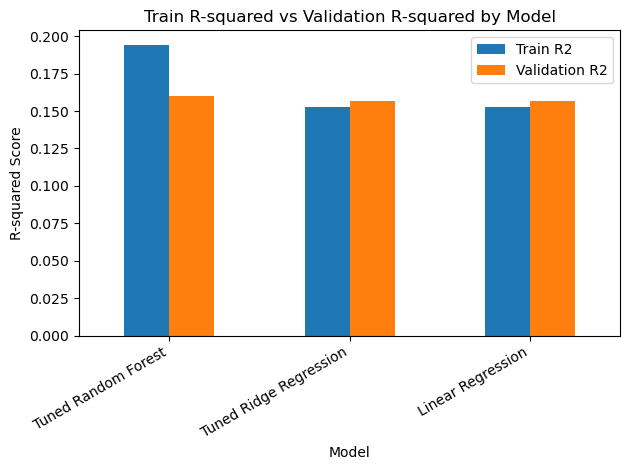

In [29]:
# 11. Visual comparison of train and validation R2
plot_df = comparison_report.set_index("Model")[["Train R2", "Validation R2"]]

plt.figure(figsize=(9, 5))
plot_df.plot(kind="bar")
plt.title("Train R-squared vs Validation R-squared by Model")
plt.ylabel("R-squared Score")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

<Figure size 900x500 with 0 Axes>

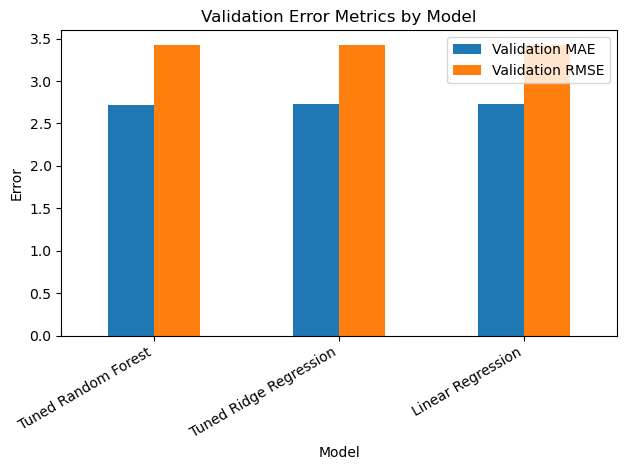

In [30]:
# 12. Visual comparison of validation MAE and RMSE
metric_df = comparison_report.set_index("Model")[["Validation MAE", "Validation RMSE"]]

plt.figure(figsize=(9, 5))
metric_df.plot(kind="bar")
plt.title("Validation Error Metrics by Model")
plt.ylabel("Error")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 13. Select Final Model Based on Validation Performance

The final model is selected using the validation results only.  
After selection, the chosen model is retrained on the combined **training + validation** data and evaluated once on the test set.

In [31]:
# 13. Select final model based on validation performance
final_model_name = comparison_df.iloc[0]["Model"]

if final_model_name == "Linear Regression":
    selected_model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ])
elif final_model_name == "Tuned Ridge Regression":
    selected_model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", Ridge(alpha=best_ridge_alpha))
    ])
else:
    selected_model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            **best_rf_params,
            random_state=42,
            n_jobs=-1
        ))
    ])

print("Final selected model based on validation performance:", final_model_name)
display(comparison_report.iloc[[0]])

Final selected model based on validation performance: Tuned Random Forest


,Model,Train R2,Validation R2,R2 Gap,Validation MAE,Validation RMSE,Fit Status
0,Tuned Random Forest,0.1942,0.1599,0.0343,2.715,3.42,Possible underfitting


## 14. Final Test Evaluation

The test set is used only at this final stage.  
The selected model is retrained on **training + validation** data before being evaluated on the test set.

In [32]:
# 14. Retrain selected model on train + validation, then evaluate on test only once
selected_model.fit(X_train_val, y_train_val)

y_train_val_pred = selected_model.predict(X_train_val)
y_test_pred = selected_model.predict(X_test)

train_val_metrics = evaluate_predictions(y_train_val, y_train_val_pred)
test_metrics = evaluate_predictions(y_test, y_test_pred)

final_test_report = pd.DataFrame([{
    "Final Model": final_model_name,
    "Train+Validation R2": train_val_metrics["R2"],
    "Test R2": test_metrics["R2"],
    "R2 Gap": train_val_metrics["R2"] - test_metrics["R2"],
    "Test MAE": test_metrics["MAE"],
    "Test RMSE": test_metrics["RMSE"]
}])

for col in ["Train+Validation R2", "Test R2", "R2 Gap", "Test MAE", "Test RMSE"]:
    final_test_report[col] = final_test_report[col].round(4)

final_test_report

,Final Model,Train+Validation R2,Test R2,R2 Gap,Test MAE,Test RMSE
0,Tuned Random Forest,0.1869,0.1598,0.027,2.6827,3.3956


## 15. Final Model Selection Justification

The final model was selected based on validation performance, robustness, and interpretability.  
The test set was not used during model selection. It was used only once after the final model had been chosen.

The model is considered more reliable if it has:

1. Higher validation and test R-squared  
2. Lower MAE and RMSE  
3. A smaller gap between training and validation/test performance  
4. Reasonable interpretability through coefficients or feature importance

In [33]:
# 15. Interpretation of the final model
interpretation_df = pd.DataFrame()
def get_feature_names(fitted_preprocessor):
    feature_names = []
    feature_names.extend(numeric_features)

    if len(categorical_features) > 0:
        cat_pipeline = fitted_preprocessor.named_transformers_["cat"]
        encoder = cat_pipeline.named_steps["onehot"]
        cat_names = encoder.get_feature_names_out(categorical_features).tolist()
        feature_names.extend(cat_names)

    return feature_names

feature_names = get_feature_names(selected_model.named_steps["preprocessor"])
model_step = selected_model.named_steps["model"]

if hasattr(model_step, "feature_importances_"):
    interpretation_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": model_step.feature_importances_
    }).sort_values(by="Importance", ascending=False).reset_index(drop=True)

    print("Top 10 important features:")
    display(interpretation_df.head(10))

elif hasattr(model_step, "coef_"):
    interpretation_df = pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": model_step.coef_
    })
    interpretation_df["Abs Coefficient"] = interpretation_df["Coefficient"].abs()
    interpretation_df = interpretation_df.sort_values(by="Abs Coefficient", ascending=False).reset_index(drop=True)

    print("Top 10 influential features by absolute coefficient:")
    display(interpretation_df.head(10))

else:
    interpretation_df = pd.DataFrame()
    print("No direct feature interpretation available for this model.")

Top 10 important features:


,Feature,Importance
0,pm2_5,0.849811
1,hospital_capacity,0.015731
2,o3,0.014352
3,no2,0.014333
4,year,0.012265
5,temperature,0.011948
6,pollution_mean,0.011562
7,pm_ratio,0.011343
8,pm10,0.010635
9,humidity,0.009748


## 16. Modeling Workflow Summary

The Class 3 modeling workflow used the ML-ready dataset from the previous stage. The target variable was clearly defined as **`hospital_admissions`**, making this a regression problem. The dataset was split into training, validation, and test sets. Three models were selected to keep the analysis focused: Linear Regression, Ridge Regression, and Random Forest Regressor. Model tuning and comparison were performed using the validation set.Overfitting and underfitting were assessed by comparing training and validation R-squared scores. After the final model was selected, it was retrained on the combined training and validation data and evaluated once on the test set. The final model was selected based on performance, robustness, and interpretability.

In [35]:
# 16. Final model comparison summary
print("=== Final Model Comparison Based on Validation Set ===")

summary_table = comparison_report[[
    "Model",
    "Train R2",
    "Validation R2",
    "R2 Gap",
    "Validation MAE",
    "Validation RMSE",
    "Fit Status"
]].copy()

summary_table = summary_table.rename(columns={
    "Train R2": "Train R-squared",
    "Validation R2": "Validation R-squared",
    "R2 Gap": "R-squared Gap"
})

display(summary_table)

=== Final Model Comparison Based on Validation Set ===


,Model,Train R-squared,Validation R-squared,R-squared Gap,Validation MAE,Validation RMSE,Fit Status
0,Tuned Random Forest,0.1942,0.1599,0.0343,2.7150,3.4200,Possible underfitting
1,Tuned Ridge Regression,0.1524,0.1568,-0.0044,2.7283,3.4263,Possible underfitting
2,Linear Regression,0.1524,0.1567,-0.0042,2.7284,3.4265,Possible underfitting
